In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""

@author: yanchen
"""
import pandas as pd
import numpy as np
np.set_printoptions(precision=4)
import matplotlib.pyplot as plt
from random import sample,choice

import warnings
warnings.filterwarnings("ignore") # To ignore warnings

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

#from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support,classification_report


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [2]:

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import scale
import matplotlib as mpl

from sklearn.preprocessing import MinMaxScaler, StandardScaler


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import RandomizedSearchCV

In [3]:
#Some constants
missing_th = 0.33
LOOK_BACK = 8
FORECAST_RANGE = 8
IS_ABSEN = True
IS_PCA = False
EXT = True #create external features
#y_col = 'RSV'
date_cols = ['year_cos','year_sin','month_cos','month_sin','week_cos','week_sin']
known_cont_cols = ['mom1','mom2','mom3'] + date_cols

In [30]:
### BUILD DATAFRAME OF EXTERNAL VARIABLES ###
def cycle_encode(data, cols, maxVal_cols = None):
    if maxVal_cols == None:
      #process training data
      maxVal_cols = []
      for i, col in enumerate(cols):
        data[col + '_sin'] = np.sin(2 * np.pi * data[col]/data[col].max())
        data[col + '_cos'] = np.cos(2 * np.pi * data[col]/data[col].max())
        maxVal_cols.append(data[col].max())
    else:
      for i, col in enumerate(cols):
        data[col + '_sin'] = np.sin(2 * np.pi * data[col]/maxVal_cols[i])
        data[col + '_cos'] = np.cos(2 * np.pi * data[col]/maxVal_cols[i])
    return data, maxVal_cols

#drop columns that have more than missing_th missing data
def drop_cols_from_missing(df,cols,missing_th = 0.33):
  cols_drop_missing = [] #cols need to be dropped because too much missing data
  for col in cols:
    #print(col, ':', df_train[col].isna().sum()/len(df_train))
    if df[col][:int(len(df))].isna().sum()/int(len(df)) > missing_th: # more than missing_th nan
        df.drop(col, axis=1, inplace=True)
        print('drop col',col)
        cols_drop_missing.append(col)
  return df, cols_drop_missing

#since time series can't backward filled, remove rows that have leading missing values
def find_backward_missing(df,cols):
  for col in df.columns.difference(['Date','Close','Name']):
        df[col] = df[col].interpolate(method='linear', limit_direction='forward') # fill nans
  return df.isnull().any(axis=1)

def create_ext_feat(df, maxVal_cols = None):
  #if there is a 'Date' column
  #if index is DatetimeIndex
  if isinstance(df.index, pd.DatetimeIndex):
    df['year'] = df.index.year
    df['month'] = df.index.month
    #df['week'] = df.index.week
    df['week'] = df.index.isocalendar()['week']
  else:
    if 'Date' in df.columns:
      df['year'] = df['Date'].dt.year
      df['month'] = df['Date'].dt.month
      df['week'] = df['Date'].dt.strftime('%V').astype('int')
      #set Date column as index
      df.set_index('Date', inplace=True)
  df, maxVal_cols = cycle_encode(df, ['year','month','week'], maxVal_cols)
  #print(maxVal_cols)
  df.drop(['year','month','week'], axis=1, inplace=True)
  return df, maxVal_cols

#create return column
def create_ret_col(df, level_col = None):
  df['ret'] = df[level_col].pct_change()*100
  df.dropna(inplace = True)
  return df

#create return label column
def create_label_col(df,n_class = 2):
  if n_class == 2:
    df['label'] = (df['ret'] > 0).astype(int)
  elif n_class == 3:
    df['label'] = pd.cut(x=df['ret'], bins=[df['ret'].min() - 1, -0.25,0.25,df['ret'].max() + 1],
                     labels=[0, 1, 2]) #0: sell, 1: neural, 2: buy
    df['label'] = df['label'].cat.codes  #convert categorical to numerical
  return df

In [37]:
#Feature selection class to eliminate multicollinearity
class MultiCollinearityEliminator():
    
    #Class Constructor
    def __init__(self, df, target, threshold):
        self.df = df
        self.target = target
        self.threshold = threshold
        self.ls_col_remove = []

    #Method to create and return the feature correlation matrix dataframe
    def createCorrMatrix(self, include_target = False):
        #Checking we should include the target in the correlation matrix
        if (include_target == False):
            df_temp = self.df.drop([self.target], axis =1)
            
            #Setting method to Pearson to prevent issues in case the default method for df.corr() gets changed
            #Setting min_period to 30 for the sample size to be statistically significant (normal) according to 
            #central limit theorem
            corrMatrix = df_temp.corr(method='pearson', min_periods=30).abs()
        #Target is included for creating the series of feature to target correlation - Please refer the notes under the 
        #print statement to understand why we create the series of feature to target correlation
        elif (include_target == True):
            corrMatrix = self.df.corr(method='pearson', min_periods=30).abs()
        return corrMatrix

    #Method to create and return the feature to target correlation matrix dataframe
    def createCorrMatrixWithTarget(self):
        #After obtaining the list of correlated features, this method will help to view which variables 
        #(in the list of correlated features) are least correlated with the target
        #This way, out the list of correlated features, we can ensure to elimate the feature that is 
        #least correlated with the target
        #This not only helps to sustain the predictive power of the model but also helps in reducing model complexity
        
        #Obtaining the correlation matrix of the dataframe (along with the target)
        corrMatrix = self.createCorrMatrix(include_target = True)                           
        #Creating the required dataframe, then dropping the target row 
        #and sorting by the value of correlation with target (in asceding order)
        corrWithTarget = pd.DataFrame(corrMatrix.loc[:,self.target]).drop([self.target], axis = 0).sort_values(by = self.target)                    
        #print(corrWithTarget, '\n')
        #corrWithTarget.to_csv('data/corrWithTarget.csv')
        return corrWithTarget

    #Method to create and return the list of correlated features
    def createCorrelatedFeaturesList(self):
        #Obtaining the correlation matrix of the dataframe (without the target)
        corrMatrix = self.createCorrMatrix(include_target = False)                          
        colCorr = []
        #Iterating through the columns of the correlation matrix dataframe
        for column in corrMatrix.columns:
            #Iterating through the values (row wise) of the correlation matrix dataframe
            for idx, row in corrMatrix.iterrows():                                            
                if(row[column]>self.threshold) and (row[column]<1):
                    #Adding the features that are not already in the list of correlated features
                    if (idx not in colCorr):
                        colCorr.append(idx)
                    if (column not in colCorr):
                        colCorr.append(column)
        #print(colCorr, '\n')
        return colCorr

    #Method to eliminate the least important features from the list of correlated features
    def deleteFeatures(self, colCorr):
        #Obtaining the feature to target correlation matrix dataframe
        corrWithTarget = self.createCorrMatrixWithTarget()                                  
        for idx, row in corrWithTarget.iterrows():
            #print(idx, '\n')
            if (idx in colCorr):
                #print(idx,row, '\n')
                self.ls_col_remove.append(idx)
                self.df = self.df.drop(idx, axis =1)
                break
        return self.df

    #Method to run automatically eliminate multicollinearity
    def autoEliminateMulticollinearity(self):
        #Obtaining the list of correlated features
        colCorr = self.createCorrelatedFeaturesList()                                       
        while colCorr != []:
            #Obtaining the dataframe after deleting the feature (from the list of correlated features) 
            #that is least correlated with the taregt
            self.df = self.deleteFeatures(colCorr)
            #Obtaining the list of correlated features
            colCorr = self.createCorrelatedFeaturesList()                                     
        #return self.df
        return self.df, self.ls_col_remove

In [61]:
def create_rolling_train_test_data(df_full, train_start_date_dt, train_end_date_dt, test_start_date_dt, test_end_date_dt, n_components = 30,y_col = None, col_date = 'date',cor_th = 0.75):
  df_rolling = df_full[df_full.columns.difference(['monthid','weekid','uid',col_date,'region'])]
  df_rolling.index = pd.to_datetime(df_full[col_date])
  df_train = df_rolling[(df_rolling.index >= train_start_date_dt) & (df_rolling.index <= train_end_date_dt)]
  df_test = df_rolling[(df_rolling.index >= test_start_date_dt) & (df_rolling.index <= test_end_date_dt)]
  
  if EXT:
    df_train, maxVal_cols = create_ext_feat(df_train)
    df_test, maxVal_cols = create_ext_feat(df_test,maxVal_cols)
  
  n_test = len(df_test)
  n_window = len(df_train)
  #df_train = df_full.iloc[end_test_row-n_test-n_window:end_test_row-n_test]
  #df_test = df_full.iloc[end_test_row-n_test:end_test_row]
  df_tmp = pd.concat([df_train,df_test],axis = 0)
  ### Scaling and PCA
  x_scaler = StandardScaler()
  #x_scaler = RobustScaler()
  df_train_X = df_train[df_train.columns.difference([y_col])]
  df_train_X_scaled = pd.DataFrame(x_scaler.fit_transform(df_train_X), columns = df_train.columns.difference([y_col,'region']), index = df_train.index)

  df_test_X = df_test[df_test.columns.difference([y_col])]
  df_test_X_scaled = pd.DataFrame(x_scaler.transform(df_test_X), columns = df_test.columns.difference([y_col,'region']), index = df_test.index)
  if IS_PCA:
    adj_n_components = min(df_train_X_scaled.shape[0], df_train_X_scaled.shape[1],n_components)
    print('adj_n_components',adj_n_components)
    pca = PCA(n_components=adj_n_components, random_state = 0)
    arr_train_X_scaled_pca = pca.fit_transform(df_train_X_scaled)
    print('explained_variance_','{:.2f}'.format(np.sum(pca.explained_variance_)))
    df_train_pca = pd.DataFrame(arr_train_X_scaled_pca,index=df_train.index, columns = ['p'+str(i) for i in range(adj_n_components)])
    df_train_pca[[y_col]] = df_train[[y_col]]

    arr_test_X_scaled_pca = pca.transform(df_test_X_scaled)
    df_test_pca = pd.DataFrame(arr_test_X_scaled_pca,index=df_test.index, columns = ['p'+str(i) for i in range(adj_n_components)])
    df_test_pca[[y_col]] = df_test[[y_col]]
    df_pca = pd.concat([df_train_pca,df_test_pca],axis = 0)
  
  else:
    df_train_X_scaled[[y_col]] = df_train[[y_col]]
    df_test_X_scaled[[y_col]] = df_test[[y_col]]
    df_train_pca = df_train_X_scaled
    df_test_pca = df_test_X_scaled
    df_pca = pd.concat([df_train_pca,df_test_pca],axis = 0)
  
  
  cols_feat = df_pca.columns.difference([y_col])
  cols_target = [y_col]
  #remove collinearity
  my_eliminator = MultiCollinearityEliminator(df_train_pca, y_col, cor_th)
  df_remove_coll,ls_removed_col = my_eliminator.autoEliminateMulticollinearity()
  #df_train_new = pd.concat((df_remove_coll,df_train_pca[y_col]),axis = 1)
  df_train_new = df_train_pca.drop(ls_removed_col, axis = 1).dropna()
  df_test_new = df_test_pca.drop(ls_removed_col, axis = 1).dropna()
  
  cols_feat_new = df_train_new.columns.difference([y_col])
  X_train,Y_train = df_train_new[cols_feat_new].values,df_train_new[cols_target].values
  X_test,Y_test = df_test_new[cols_feat_new].values,df_test_new[cols_target].values
  Y_train_date,Y_test_date = df_train_new.index,df_test_new.index
  
  Y_train = Y_train.squeeze()
  Y_test = Y_test.squeeze() #randomregressor can only accept 2d data, not 3d
  return X_train,Y_train,X_test,Y_test, Y_train_date, Y_test_date,df_train_new,df_test_new

In [12]:
import os
#os.getcwd()
pwd=os.path.abspath(os.path.dirname(os.getcwd()))
print(pwd)

c:\Users\yanch\Dropbox\hksph\hksph-project\gpce-covid-main\TFT-pytorch


In [48]:

#os.chdir('c:\\Users\\yanch\\OneDrive - purdue.edu\\hksph-project\\flu_data')
os.chdir('c:\\Users\\yanch\\Dropbox\\hksph\\hksph-project\\flu_data')
#os.chdir('/Users/yanchen/Documents/flu_data')
file_name = 'hk_data_org.csv'
df_raw=pd.read_csv(file_name)
#df_raw['date'] = pd.to_datetime(df_raw['date'] , format = '%Y-%m-%d')
#replace dot with underscore
df_raw.columns = [c.replace('.', '_') for c in df_raw.columns]
#df_raw.head()

In [49]:
#os.chdir('/Users/yanchen/Documents/flu_data')
df_absence=pd.read_csv('ts_week.csv',index_col=0)

#replace dot with underscore
df_absence.columns = [c.replace('.', '_') for c in df_absence.columns]
df_absence.head()

df_merged = df_raw.merge(df_absence[['date', 'absent_proportion']], on = 'date', how = 'left')

In [50]:
col_pos_rates = ['h1_pos', 'sh3_pos','b_pos', 'Adenovirus', 'paraflu12', 'paraflu34', 'RSV']
cols_pos_cases = [col + '_case' for col in col_pos_rates]
#2004-2008-9/7 data is missing
start_row = np.where(df_merged['absent_proportion'].isnull()==0)[0][0]
if IS_ABSEN:
    #df_raw_adj = df_merged.copy()
    df_raw_adj = df_merged.iloc[start_row:,:]
    df_raw_adj.reset_index(inplace = True, drop = True)
else:
    df_raw_adj = df_raw.copy() 
for col in col_pos_rates:
    df_raw_adj[col + '_case'] = df_raw_adj[col]*df_raw_adj["rate_All"]
#df_raw['all_flu'] = df_raw['h1_pos'] + df_raw['sh3_pos'] + df_raw['b_pos']
df_raw_adj.drop(col_pos_rates + ['rate_All'], axis=1,inplace= True)
df_raw_adj.head()

,region,uid,date,weekid,temp_max,temp_mean,temp_min,relative_humidity,total_rainfall,solar_radiation,...,temp_range,monthid,absent_proportion,h1_pos_case,sh3_pos_case,b_pos_case,Adenovirus_case,paraflu12_case,paraflu34_case,RSV_case
0,HK,2008-36,2008-09-07,36,32.4,28.185714,27.7,81.428571,7.621429,14.931429,...,4.842857,9,1.2,0.768145,2.765320,0.409677,1.382660,0.153629,0.307258,3.738304
1,HK,2008-37,2008-09-14,37,34.2,29.600000,28.4,68.571429,0.035714,21.267143,...,5.057143,9,1.5,0.742887,1.609588,0.330172,0.701615,0.206357,0.660344,3.631890
2,HK,2008-38,2008-09-21,38,33.8,29.757143,29.0,74.571429,3.585714,15.581429,...,4.828571,9,1.6,0.981162,1.407754,0.213296,0.725207,0.127978,0.298615,2.559554
3,HK,2008-39,2008-09-28,39,34.3,28.671429,28.3,77.142857,11.521429,14.671429,...,5.628571,9,3.2,0.293523,0.929489,0.293523,1.223012,0.440284,0.440284,2.250343
4,HK,2008-40,2008-10-05,40,31.8,27.014286,25.5,75.857143,20.285714,13.350000,...,5.100000,10,2.2,0.255055,0.969209,0.000000,0.714154,0.102022,0.918198,3.417738


In [51]:
col_date = 'date'
df_raw_adj[col_date] = pd.to_datetime(df_raw_adj[col_date] , format = '%Y-%m-%d')
min_date = df_raw_adj[col_date].min()
max_date = df_raw_adj[col_date].max()
print(min_date)
print(max_date)

col_region = 'region'
ls_regions = df_raw_adj[col_region].unique()
print(df_raw_adj[col_region].unique())
print(df_raw_adj[col_region].unique().shape)

df_raw_adj['all_flu_case'] = df_raw_adj['h1_pos_case'] + df_raw_adj['sh3_pos_case'] + df_raw_adj['b_pos_case']

col_value = ['region','all_flu_case','h1_pos_case','sh3_pos_case','b_pos_case','Adenovirus_case','paraflu12_case','paraflu34_case', 'RSV_case']
col_value_noregion = ['all_flu_case','h1_pos_case','sh3_pos_case','b_pos_case','Adenovirus_case', 'paraflu12_case','paraflu34_case', 'RSV_case']

if IS_ABSEN:
#fill with 95% percentile
    df_raw_adj['absent_proportion'] = df_raw_adj['absent_proportion'].fillna(7.085)

2008-09-07 00:00:00
2019-12-29 00:00:00
['HK']
(1,)


In [52]:
remove_start_date = '2009-04-01'
#remove_start_date_dt = datetime.strptime(test_start_date, '%Y-%m-%d')
remove_end_date = '2010-03-31'
#remove_end_date_dt = datetime.strptime(test_start_date, '%Y-%m-%d')
print(df_raw_adj.shape)
#df_raw_adj3 = copy.deepcopy(df_raw_adj)
df_raw_adj =df_raw_adj.loc[~((df_raw_adj.date >= remove_start_date)&(df_raw_adj.date <= remove_end_date)),:]
#df_raw_adj =df_raw_adj.loc[(df_raw_adj.date > remove_end_date_dt),:]
df_raw_adj.reset_index(inplace = True, drop = True)
print(df_raw_adj.shape)

(591, 24)
(539, 24)


In [53]:
#y_col = 'all_flu'
y_col = 'all_flu_case'
#x_cols = [col for col in col_value_noregion if col != y_col]
x_cols = [col for col in df_raw_adj.columns.difference(['weekid','monthid','uid',col_date,col_region]) if col != y_col]
print(x_cols)
location_col = 'region'
targets = [y_col]

col_temp = [x for x in x_cols if x not in col_value_noregion]
x_cols_unknown = [x for x in x_cols if x not in col_temp]
known_cols = date_cols + col_temp

['Adenovirus_case', 'RSV_case', 'absent_proportion', 'absolute_humidity', 'b_pos_case', 'h1_pos_case', 'paraflu12_case', 'paraflu34_case', 'pressure', 'relative_humidity', 'sh3_pos_case', 'solar_radiation', 'temp_max', 'temp_mean', 'temp_min', 'temp_range', 'total_rainfall', 'wind_speed']


In [54]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series,title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    #print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)
    for key,val in result[4].items():
        out[f'critical value ({key})']=val
    #print(out.to_string())          # .to_string() removes the line "dtype: float64"
    #if result[1] <= 0.05:
        #print("Strong evidence against the null hypothesis")
        #print("Reject the null hypothesis")
        #print("Data has no unit root and is stationary")
    #else:
        #print("Weak evidence against the null hypothesis")
        #print("Fail to reject the null hypothesis")
        #print("Data has a unit root and is non-stationary")
    return result[1]

In [ ]:
"""
for i,col in enumerate(df_raw_adj.columns.difference([y_col,'region','date','uid','weekid','monthid'])):
    print(i)
    print(col)
    adf_pvalue = adf_test(df_raw_adj[col])
    if adf_pvalue>0.05:
        print('Differentiation because of ADFtest')
        #col_diff = df_raw_adj[col].diff()
        df_raw_adj[col+'_diff'] = pd.concat([pd.Series(0),df_raw_adj[col].diff()],ignore_index=True)
"""

In [232]:
from pandas import DataFrame, to_datetime, to_timedelta
from datetime import datetime

test_size = 8
train_size = 2555

test_start_date0 = '2013-11-01'
test_start_date0_dt = datetime.strptime(test_start_date0, '%Y-%m-%d')

df_full = df_raw_adj
iteration = 0
test_start_date_dt = min(test_start_date0_dt + to_timedelta(365*iteration, unit='day'),max_date)
test_end_date_dt = min(test_start_date_dt + to_timedelta(test_size, unit='W'),max_date)
train_end_date_dt = test_start_date_dt - to_timedelta(1, unit='W')
train_start_date_dt = min_date

print('train_end_date_dt',  train_end_date_dt)
print('test_start_date_dt',  test_start_date_dt)
X_train,Y_train,X_test,Y_test, Y_train_date, Y_test_date,df_train,df_test = create_rolling_train_test_data(df_full, train_start_date_dt,train_end_date_dt, 
                                                                                                           test_start_date_dt, test_end_date_dt, 
                                                                                                           n_components = 30,y_col = y_col, cor_th = 0.5)
print('number of features',X_train.shape[1])

#x_train, x_val, y_train, y_val = train_test_split(X_train, Y_train, shuffle=False, train_size=0.8)

train_end_date_dt 2013-10-25 00:00:00
test_start_date_dt 2013-11-01 00:00:00
number of features 13


In [235]:
Y_test.shape[0]

8

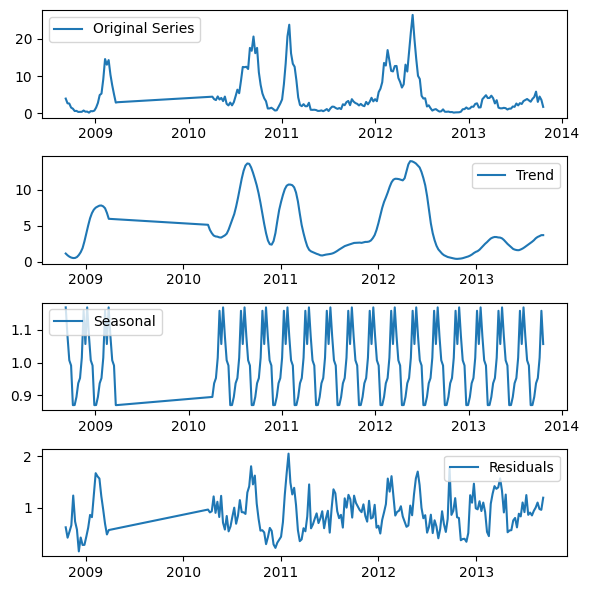

In [190]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df_train[y_col], model='multiplicative', period=12)
trend = result.trend.dropna()
seasonal = result.seasonal.dropna()
residual = result.resid.dropna()

# Plot the decomposed components
plt.figure(figsize=(6,6))

plt.subplot(4, 1, 1)
plt.plot(df_train[y_col], label='Original Series')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals')
plt.legend()

plt.tight_layout()
plt.show()


In [192]:
!pip install pmdarima -q
import pmdarima as pm

In [193]:
SARIMAX_model = pm.auto_arima(Y_train, exogenous=X_train,
						start_p=1, start_q=1,
						test='adf',
						max_p=3, max_q=3, m=12,
						start_P=0, seasonal=True,
						d=None, D=1,
						trace=False,
						error_action='ignore',
						suppress_warnings=True,
						stepwise=True)

In [223]:
def sarimax_forecast(SARIMAX_model, periods=24):
	# Forecast
	n_periods = periods
    
	fitted, confint = SARIMAX_model.predict(n_periods=n_periods,
											return_conf_int=True,
											exogenous=X_test)
	index_of_fc = pd.date_range(df_test.index[0], periods=n_periods, freq='W')

	df_result = pd.DataFrame(np.concatenate((Y_test.reshape(-1,1),fitted.reshape(-1,1)
										  ,confint),axis = 1),
										 columns = ['true','pred','lower','upper'])
	df_result.index = index_of_fc

	# Plot
	plt.figure(figsize=(15, 7))

	df_result.plot()
	plt.fill_between(df_result.index,
					df_result['lower'],
					df_result['upper'],
					color='k', alpha=.15)

	plt.title("SARIMAX - Forecast")
	plt.show()
	return fitted,confint,index_of_fc


<Figure size 1500x700 with 0 Axes>

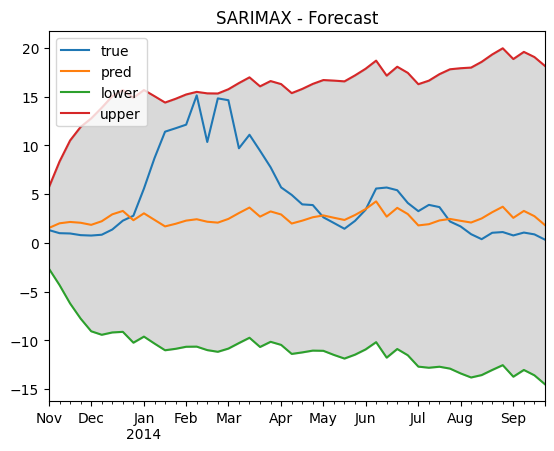

In [224]:
fitted,confint,index_of_fc = sarimax_forecast(SARIMAX_model, periods=X_test.shape[0])

In [69]:
from scipy.special import expit, logit
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [70]:
### FIT AND FIND BEST MODEL ###
#without exog
all_res = {}
best_model = None
best_aic, best_order = np.inf, 0

for p in range(1,20):
    for q in range(0,2):
        for d in range(0,2):
            m = SARIMAX(endog = Y_train,
                    order=(p,d,q), enforce_invertibility=False)
            try:
                model = m.fit(disp=False)
                all_res[(p,d,q)] = model.aic
            except:
                all_res[(p,d,q)] = np.inf

            if all_res[(p,d,q)] < best_aic:
                best_aic = all_res[(p,d,q)]
                best_order = (p,d,q)
                best_model = model

print('BEST ORDER', best_order, 'BEST AIC:', best_aic)

c:\Users\yanch\anaconda3\envs\deepflu\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


BEST ORDER (7, 1, 1) BEST AIC: 884.0870789066237


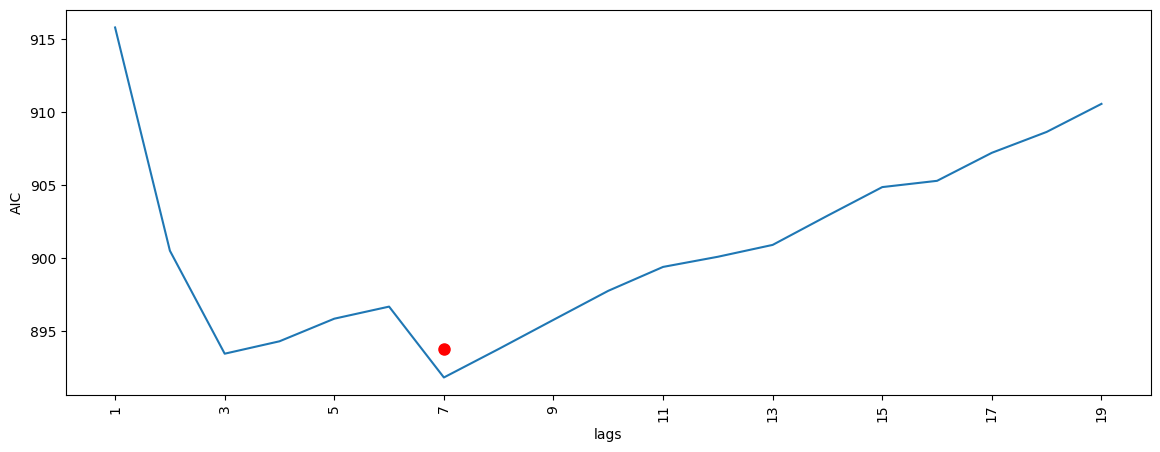

In [71]:
import itertools
# set parameter range
p = range(1,20)
d = [0]
q = [0]
# list of all parameter combos
pdq = list(itertools.product(p, d, q))
ls_aic = [all_res[key] for key in pdq]

### PLOT AICs ###

plt.figure(figsize=(14,5))
plt.plot(p, ls_aic)
plt.plot([best_order[0]], [ls_aic[best_order[0]]], marker='o', markersize=8, color="red")
plt.xticks(range(1,len(ls_aic)+1, 2), range(1,20, 2), rotation=90)
plt.xlabel('lags'); plt.ylabel('AIC')
np.set_printoptions(False)

best_model.plot_diagnostics(figsize=(12,8))

In [127]:
#n_forecast = Y_test.shape[0]
predict = best_model.get_prediction(end=best_model.nobs + FORECAST_RANGE - 1)
proba = predict.predicted_mean
proba[-FORECAST_RANGE:]

array([0.8644, 0.6469, 1.2143, 1.296 , 1.8382, 2.4797, 3.1436, 3.5911])

In [167]:
for j in range(X_test.shape[0])[::FORECAST_RANGE]:
#for j in range(X_test.shape[0]-FORECAST_RANGE+1):
         j1 = min(X_test.shape[0],j+FORECAST_RANGE)
         x_test = X_test[j:j1,:]
         print(j)
         print(x_test.shape)

0
(8, 13)
8
(8, 13)
16
(8, 13)
24
(8, 13)
32
(8, 13)
40
(8, 13)


In [253]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_log_error, explained_variance_score

# https://pytorch-forecasting.readthedocs.io/en/stable/api/pytorch_forecasting.metrics.point.SMAPE.html?highlight=smape
def symmetric_mean_absolute_percentage(y_true, y_pred):
    value = 2*abs(y_true - y_pred) / (abs(y_true) + abs(y_pred))
    # for cases when both ground truth and predicted value are zero
    value = np.where(np.isnan(value), 0, value)

    return np.mean(value)

# https://en.wikipedia.org/wiki/Nash%E2%80%93Sutcliffe_model_efficiency_coefficient
# NSE is equivalent to https://scikit-learn.org/stable/modules/generated/sklearn.metrics.explained_variance_score.html#sklearn.metrics.explained_variance_score
def normalized_nash_sutcliffe_efficiency(y_true, y_pred):
    # numerator = sum (np.square(y_true - y_pred) )
    # denominator = sum(np.square(y_true - np.mean(y_true)))
    # NSE = 1 - numerator / denominator
    NSE = explained_variance_score(y_true, y_pred)
    return 1 / ( 2 - NSE)

def calculate_result(y_true, y_pred,print_option = True):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    #rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
    smape = symmetric_mean_absolute_percentage(y_true, y_pred)
    nnse = normalized_nash_sutcliffe_efficiency(y_true, y_pred)
    if print_option:
        print(f'MAE {mae:.5g}, RMSE {rmse:.5g}, SMAPE {smape:0.5g}, NNSE {nnse:0.5g}.')
    return mae, rmse, smape, nnse

def convert_multi_pred_to_single(predictions,time_index):
    results = {}
    #predictions = ls_y_test_pred[round0]
    #time_index = y_test_date_idx
    for index in range(len(predictions)):
            current_time_index = time_index[index]

            for time_step in range(FORECAST_RANGE):
                if index+time_step< len(predictions):
                    item = time_index[index+time_step]
                    predicted_value = predictions[index][time_step]

                    if item in results:
                        results[item].append(predicted_value)
                    else:
                        results[item] = [predicted_value]

    adj_predictions = []
    for key in results.keys():
            item = results[key]

            adj_predictions.append(np.mean(item))
        
    result_df = pd.DataFrame({
            f'Predicted_{y_col}': adj_predictions  
        })
    return result_df

In [263]:
## train model in a rolling manner
def my_rolling_train(df_full,test_size = FORECAST_RANGE, y_col = y_col,
                     train_start_fix = 1,p = 6, d = 1, q = 1):
  #n_round: number of rolling windows
  ls_Y_test_pred = []
  ls_y_train_pred = []
  ls_aic = []
  ls_df_test_result = []

  ls_Y_test_date = []
  ls_Y_test = []
  ls_Y_train = []
  ls_Y_train_date = []



  #test_start_date_dt = test_start_date0_dt
  iteration = 0
  for _ in range(df_full.shape[0]-216-test_size)[::test_size]:
    iteration +=1
    print('iteration',  iteration)
    
    test_start_date_dt = min(test_start_date0_dt + to_timedelta(test_size*(iteration-1), unit='W'),max_date)
    test_end_date_dt = min(test_start_date_dt + to_timedelta(test_size, unit='W'),max_date)
    #test_start_date_dt = min(test_start_date0_dt + to_timedelta(365*iteration, unit='day'),max_date)
    #test_end_date_dt = min(test_start_date_dt + to_timedelta(test_size, unit='day'),max_date)
    train_end_date_dt = test_start_date_dt - to_timedelta(1, unit='W')
    if train_start_fix ==1:
      train_start_date_dt = min_date
    else:
      train_start_date_dt = max(train_end_date_dt - to_timedelta(train_size, unit='day'),min_date)
    
    print('train_end_date_dt',  train_end_date_dt)
    print('test_start_date_dt',  test_start_date_dt)
    print('test_end_date_dt',  test_end_date_dt)
    X_train,Y_train,X_test,Y_test, Y_train_date, Y_test_date,_,_ = create_rolling_train_test_data(df_full, train_start_date_dt,train_end_date_dt, test_start_date_dt, test_end_date_dt, n_components = 30,y_col = y_col, cor_th = 0.5)
    print('number of features',X_train.shape[1])
    ls_Y_test_date.append(Y_test_date)
    ls_Y_test.append(Y_test)

    ls_Y_train_date.append(Y_train_date)
    ls_Y_train.append(Y_train)

    
    m = SARIMAX(endog = Y_train,
                    order=(p,d,q), 
                    enforce_invertibility=False)
    try:
                model = m.fit(disp=False)
                ls_aic.append(model.aic)
    except:
                ls_aic.append(np.inf)
    
    
    
    
    n_forecast = Y_test.shape[0]
    predict = model.get_prediction(end=model.nobs + n_forecast - 1)
    predict_mean = predict.predicted_mean
    y_test_pred = predict_mean[-n_forecast:]
    ls_Y_test_pred.append(y_test_pred)
    """
    SARIMAX_model = pm.auto_arima(Y_train, exogenous=X_train,
						start_p=1, start_q=1,
						test='adf',
						max_p=3, max_q=3, m=12,
						start_P=0, seasonal=True,
						d=None, D=1,
						trace=False,
						error_action='ignore',
						suppress_warnings=True,
						stepwise=True)

    n_forecast = Y_test.shape[0]
    fitted, confint = SARIMAX_model.predict(n_periods=n_forecast,
											return_conf_int=True,
											exogenous=X_test)
    index_of_fc = pd.date_range(df_test.index[0], periods=n_forecast, freq='W')

    df_result = pd.DataFrame(np.concatenate((Y_test.reshape(-1,1),fitted.reshape(-1,1)
										  ,confint),axis = 1),
										 columns = ['true','pred','lower','upper'])
    df_result.index = index_of_fc
    mae, rmse, smape, nnse = calculate_result(Y_test, fitted)
    ls_df_test_result.append(df_result)
    """
    
  return ls_Y_test_pred,ls_Y_test,ls_Y_test_date

In [264]:
test_size = 8
ls_Y_test_pred,ls_Y_test,ls_Y_test_date = my_rolling_train(df_raw_adj, test_size = FORECAST_RANGE, y_col = y_col,p = 6, d = 1, q = 1)

iteration 1
train_end_date_dt 2013-10-25 00:00:00
test_start_date_dt 2013-11-01 00:00:00
test_end_date_dt 2013-12-27 00:00:00
number of features 13
iteration 2
train_end_date_dt 2013-12-20 00:00:00
test_start_date_dt 2013-12-27 00:00:00
test_end_date_dt 2014-02-21 00:00:00
number of features 13
iteration 3
train_end_date_dt 2014-02-14 00:00:00
test_start_date_dt 2014-02-21 00:00:00
test_end_date_dt 2014-04-18 00:00:00
number of features 13
iteration 4
train_end_date_dt 2014-04-11 00:00:00
test_start_date_dt 2014-04-18 00:00:00
test_end_date_dt 2014-06-13 00:00:00
number of features 13
iteration 5
train_end_date_dt 2014-06-06 00:00:00
test_start_date_dt 2014-06-13 00:00:00
test_end_date_dt 2014-08-08 00:00:00
number of features 13
iteration 6
train_end_date_dt 2014-08-01 00:00:00
test_start_date_dt 2014-08-08 00:00:00
test_end_date_dt 2014-10-03 00:00:00
number of features 13
iteration 7
train_end_date_dt 2014-09-26 00:00:00
test_start_date_dt 2014-10-03 00:00:00
test_end_date_dt 2014-1

In [265]:
ls_df_test_compare = []
ls_y_pred = []
ls_y_true = []
for round0 in range(len(ls_Y_test_pred)):
  round1 = round0 + 1
  y_test_date_idx = ls_Y_test_date[round0]
  y_test_pred = ls_Y_test_pred[round0].flatten()
  #y_test_pred = ls_df_test_result[round0]['pred'].values.flatten()
  y_test = ls_Y_test[round0].flatten()

  """
  train_temp = ls_Y_train_date[round0][0]

  train_timestamp = ((train_temp - np.datetime64('1970-01-01T00:00:00'))
                 / np.timedelta64(1, 's'))

  print('train start date: ',datetime.utcfromtimestamp(train_timestamp))
  """
  test_temp = ls_Y_test_date[round0][0]

  test_timestamp = ((test_temp - np.datetime64('1970-01-01T00:00:00'))
                 / np.timedelta64(1, 's'))

  print('test start date: ',datetime.utcfromtimestamp(test_timestamp))
  #mae, rmse, rmsle, smape, nnse = calculate_result(y_test, y_test_pred)

  
  #if FORECAST_RANGE>1:
  if len(ls_Y_test_pred[round0].shape)>1:
    single_pred = convert_multi_pred_to_single(ls_Y_test_pred[round0],y_test_date_idx)
    single_test = convert_multi_pred_to_single(ls_Y_test[round0],y_test_date_idx)
  else:
    single_pred = y_test_pred
    single_test = y_test
  
  mae, rmse, smape, nnse = calculate_result(single_test, single_pred)
  ls_y_pred.append(single_pred)
  ls_y_true.append(single_test)

  df_test_compare = pd.DataFrame(np.hstack((single_test.reshape(-1,1),
                                          single_pred.reshape(-1,1))),
                               columns = ['y_test','y_pred'])
  df_test_compare.index = y_test_date_idx
  print(df_test_compare.std())
  ls_df_test_compare.append(df_test_compare.std())
  title_str = 'RF Regression test actual vs test predicted'
  """
  plt.plot(df_test_compare.index, df_test_compare['y_pred'], label = 'y_pred')
  plt.plot(df_test_compare.index, df_test_compare['y_test'], label = 'y_test')

  plt.xticks(rotation=90)
  plt.legend()
  plt.title(title_str)
  plt.show()
  """

test start date:  2013-11-03 00:00:00
MAE 0.46009, RMSE 0.54547, SMAPE 0.62817, NNSE 0.67545.
y_test    0.506009
y_pred    0.531547
dtype: float64
test start date:  2013-12-29 00:00:00
MAE 8.088, RMSE 8.8881, SMAPE 1.3238, NNSE 0.50053.
y_test    3.943963
y_pred    0.108398
dtype: float64
test start date:  2014-02-23 00:00:00
MAE 3.9976, RMSE 4.7146, SMAPE 0.39322, NNSE 0.65601.
y_test    3.689862
y_pred    1.047081
dtype: float64
test start date:  2014-04-20 00:00:00
MAE 1.0398, RMSE 1.1999, SMAPE 0.33424, NNSE 0.58889.
y_test    1.326348
y_pred    0.488466
dtype: float64
test start date:  2014-06-15 00:00:00
MAE 1.9233, RMSE 2.1548, SMAPE 0.46921, NNSE 0.35622.
y_test    1.388901
y_pred    0.532778
dtype: float64
test start date:  2014-08-10 00:00:00
MAE 2.199, RMSE 2.3458, SMAPE 1.1431, NNSE 0.10569.
y_test    0.300239
y_pred    0.762299
dtype: float64
test start date:  2014-10-05 00:00:00
MAE 2.7957, RMSE 3.0207, SMAPE 1.6215, NNSE 0.016686.
y_test    0.159318
y_pred    1.135145
dt

In [262]:
#with exg
total_y_pred = np.concatenate(ls_y_pred)
total_y_true = np.concatenate(ls_y_true)
mae, rmse, smape, nnse = calculate_result(total_y_true, total_y_pred)

MAE 3.5587, RMSE 5.0297, SMAPE 0.87147, NNSE 0.53297.


In [267]:
#without exg
total_y_pred = np.concatenate(ls_y_pred)
total_y_true = np.concatenate(ls_y_true)
mae, rmse, smape, nnse = calculate_result(total_y_true, total_y_pred)

MAE 3.1658, RMSE 4.5865, SMAPE 0.74133, NNSE 0.57939.


In [76]:
### FIT AND FIND BEST MODEL ###
#with exog
all_res_exog = {}
best_model_exog = None
best_aic_exog, best_order_exog = np.inf, 0

for p in range(1,20):
    for q in range(0,2):
        for d in range(0,2):

            m = SARIMAX(endog = Y_train,
                    exog = X_train,
                    order=(p,d,q), enforce_invertibility=False)

            try:
                model = m.fit(disp=False)
                all_res_exog[(p,d,q)] = model.aic
            except:
                all_res_exog[(p,d,q)] = np.inf

            if all_res_exog[(p,d,q)] < best_aic_exog:
                best_aic_exog = all_res_exog[(p,d,q)]
                best_order_exog = (p,d,q)
                best_model_exog = model

c:\Users\yanch\anaconda3\envs\deepflu\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\yanch\anaconda3\envs\deepflu\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\yanch\anaconda3\envs\deepflu\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\yanch\anaconda3\envs\deepflu\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\yanch\anaconda3\envs\deepflu\lib\site-p

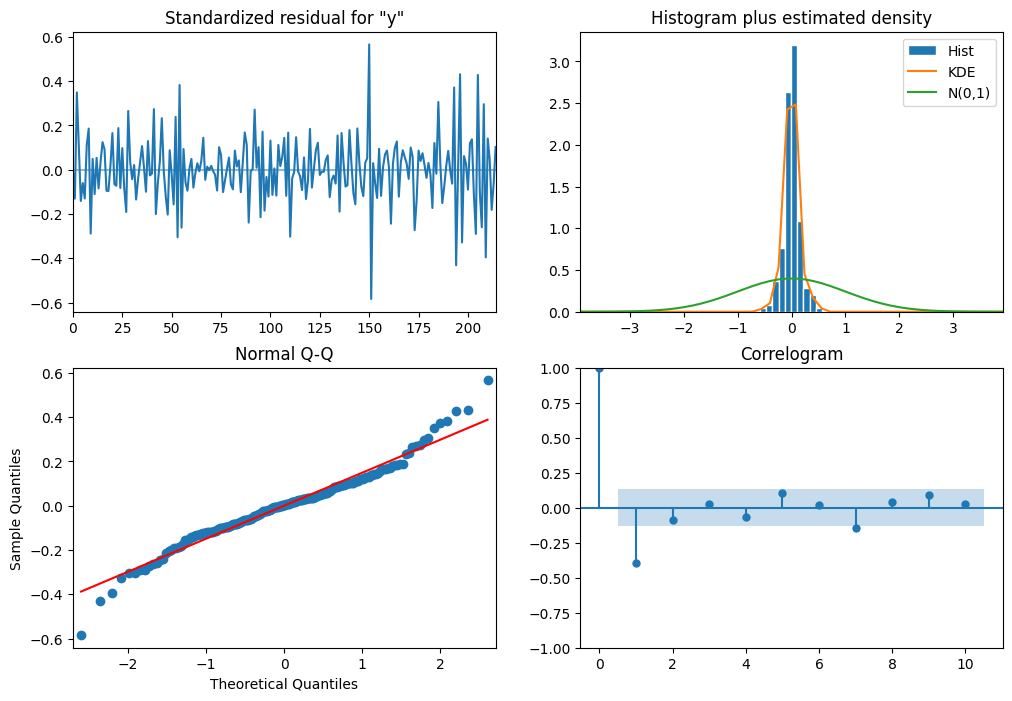

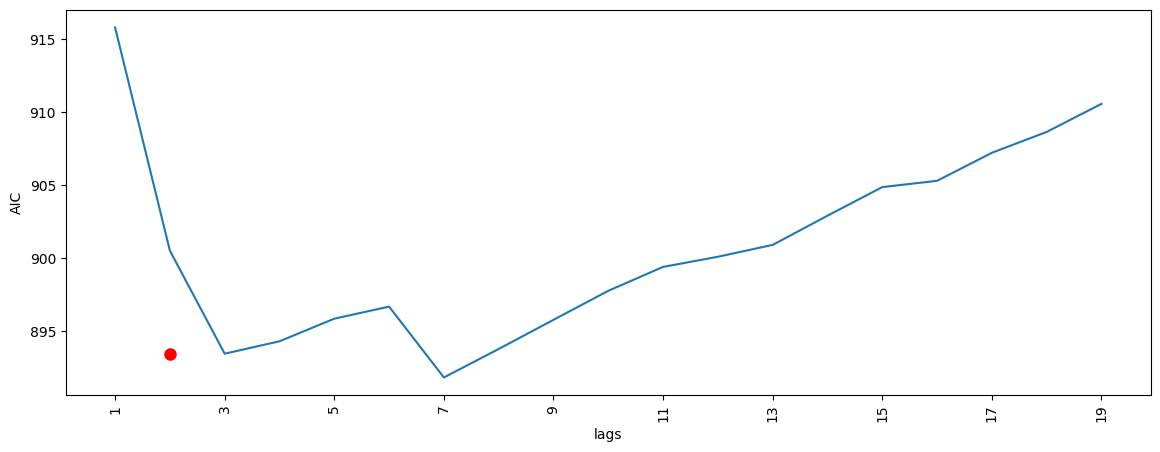

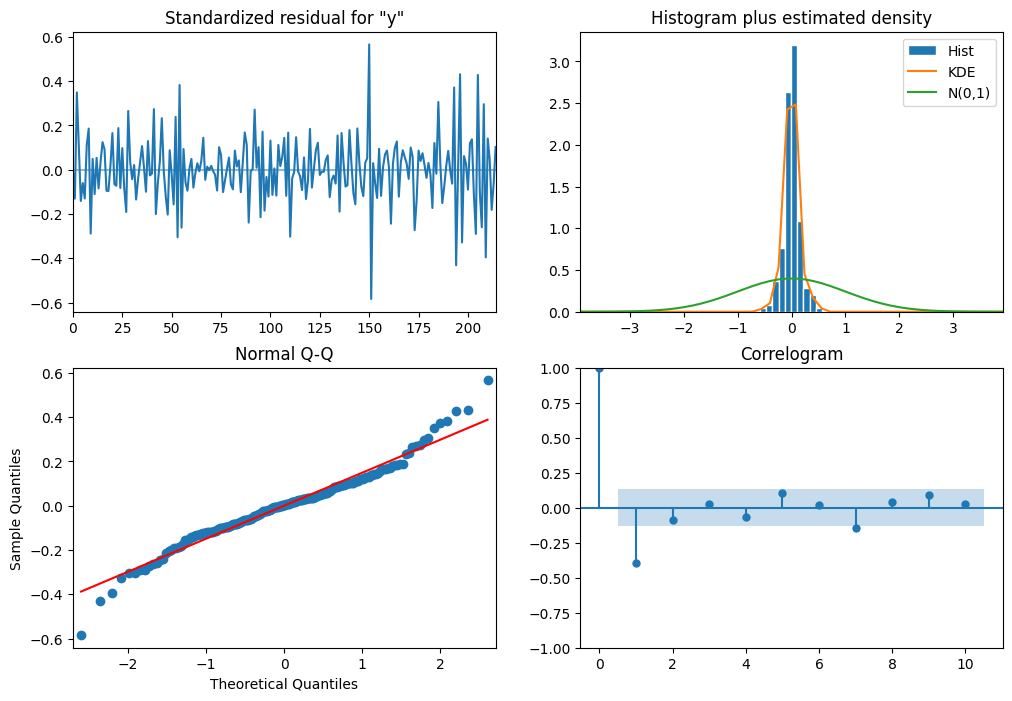

In [80]:
import itertools
# set parameter range
p = range(1,20)
d = [0]
q = [0]
# list of all parameter combos
pdq = list(itertools.product(p, d, q))
ls_aic = [all_res[key] for key in pdq]

### PLOT AICs ###

plt.figure(figsize=(14,5))
plt.plot(p, ls_aic)
plt.plot([best_order_exog[0]], [ls_aic[best_order_exog[0]]], marker='o', markersize=8, color="red")
plt.xticks(range(1,len(ls_aic)+1, 2), range(1,20, 2), rotation=90)
plt.xlabel('lags'); plt.ylabel('AIC')
np.set_printoptions(False)

best_model_exog.plot_diagnostics(figsize=(12,8))

In [81]:
best_order_exog

(2, 1, 1)